# Задача 6. BFS on GPU

## Задание

Используя OpenCL или CUDA реализовать алгоритм обхода в ширину ориентированного графа на GPU. Реализация не обязательно должна использовать операции линейной алгебры, можно взять классический алгоритм BFS.
Провести экспериментальное исследование полученной реализации и сравнить её с реализацией этого же алгоритма на CPU. Графы брать разного размера, например с сайта SuiteSparse Matrix Collection. На некоторых 
графах добиться прироста производительности при использовании GPU.


## Решение

### Импорт

In [26]:
from collections import deque
import numpy as np
import scipy.sparse as sp
from scipy.io import mmread
import matplotlib.pyplot as plt
import pandas as pd
import pyopencl as cl
import requests
import tarfile
import io
import os
import time

#### Загрузка графов С SuiteSparse

In [27]:
# Список графов
GRAPHS_TO_DOWNLOAD = [
    # Социальные сети (scale-free, малый диаметр — GPU выигрывает)
    ("SNAP", "p2p-Gnutella04"),      #  11K вершин,   40K рёбер
    ("SNAP", "p2p-Gnutella25"),      #  22K вершин,   54K рёбер
    ("SNAP", "p2p-Gnutella31"),      #  63K вершин,  147K рёбер
    ("SNAP", "amazon0302"),          # 262K вершин,  899K рёбер
    ("SNAP", "amazon0601"),          # 403K вершин, 2.4M рёбер

    # Веб-графы (большие, высокая степень)
    ("Gleich", "wb-cs-stanford"),    #   9K вершин,   36K рёбер
    ("SNAP",   "web-Stanford"),      # 281K вершин, 1.9M рёбер
    ("SNAP",   "web-NotreDame"),     # 325K вершин, 1.5M рёбер

    # Дорожные сети (большой диаметр — CPU выигрывает, интересно для сравнения)
    ("SNAP", "roadNet-PA"),          # 1.1M вершин, 1.5M рёбер
    ("SNAP", "roadNet-CA"),          # 2.0M вершин, 2.8M рёбер

    # Email-графы
    ("SNAP", "email-EuAll"),         # 265K вершин, 364K рёбер
    ("SNAP", "email-Enron"),         #  37K вершин, 183K рёбер
]

CACHE_DIR = "suitesparse_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

def download_graph(group, name):
    """Скачать .mtx граф с SuiteSparse, вернуть CSR-матрицу."""
    local_path = os.path.join(CACHE_DIR, f"{name}.mtx")

    if os.path.exists(local_path):
        print(f"  [cache] {name}")
    else:
        url = f"https://suitesparse-collection-website.herokuapp.com/MM/{group}/{name}.tar.gz"
        print(f"  [download] {name}  ←  {url}")
        try:
            resp = requests.get(url, timeout=120)
            resp.raise_for_status()
            with tarfile.open(fileobj=io.BytesIO(resp.content)) as tar:
                for member in tar.getmembers():
                    if member.name.endswith(".mtx"):
                        with open(local_path, "wb") as f:
                            f.write(tar.extractfile(member).read())
                        break
        except Exception as e:
            print(f"  [ERROR] не удалось скачать {name}: {e}")
            return None, None

    try:
        A = mmread(local_path).tocsr().astype(np.float32)
        # Убираем диагональ и нули
        A.setdiag(0)
        A.eliminate_zeros()
        return name, A
    except Exception as e:
        print(f"  [ERROR] не удалось прочитать {name}: {e}")
        return None, None

print("Загрузка графов с https://sparse.tamu.edu/ ...")
graphs = []
for group, name in GRAPHS_TO_DOWNLOAD:
    label, A = download_graph(group, name)
    if A is not None:
        n, m = A.shape[0], A.nnz
        print(f"    OK  {label:30s}  V={n:>7,}  E={m:>9,}")
        graphs.append((label, A))

print(f"\nЗагружено графов: {len(graphs)}")

Загрузка графов с https://sparse.tamu.edu/ ...
  [download] p2p-Gnutella04  ←  https://suitesparse-collection-website.herokuapp.com/MM/SNAP/p2p-Gnutella04.tar.gz
    OK  p2p-Gnutella04                  V= 10,879  E=   39,994
  [download] p2p-Gnutella25  ←  https://suitesparse-collection-website.herokuapp.com/MM/SNAP/p2p-Gnutella25.tar.gz
    OK  p2p-Gnutella25                  V= 22,687  E=   54,705
  [download] p2p-Gnutella31  ←  https://suitesparse-collection-website.herokuapp.com/MM/SNAP/p2p-Gnutella31.tar.gz
    OK  p2p-Gnutella31                  V= 62,586  E=  147,892
  [download] amazon0302  ←  https://suitesparse-collection-website.herokuapp.com/MM/SNAP/amazon0302.tar.gz
    OK  amazon0302                      V=262,111  E=1,234,877
  [download] amazon0601  ←  https://suitesparse-collection-website.herokuapp.com/MM/SNAP/amazon0601.tar.gz
    OK  amazon0601                      V=403,394  E=3,387,388
  [download] wb-cs-stanford  ←  https://suitesparse-collection-website.herokuap

### CPU BFS

In [28]:
def bfs_cpu(row_ptr, col_ind, n, source):
    dist = np.full(n, -1, dtype=np.int32)
    dist[source] = 0
    queue = deque([source])
    t0 = time.perf_counter()
    while queue:
        u = queue.popleft()
        d = dist[u]
        for i in range(row_ptr[u], row_ptr[u + 1]):
            v = col_ind[i]
            if dist[v] == -1:
                dist[v] = d + 1
                queue.append(v)
    return dist, time.perf_counter() - t0

### GPU BFS

In [29]:
BFS_KERNEL_SRC = r"""
__kernel void bfs_step(
    __global const int* row_ptr,
    __global const int* col_ind,
    __global const int* frontier,
    const int frontier_size,
    __global int* dist,
    __global int* next_frontier,
    __global int* next_size,
    const int current_dist
) {
    int gid = get_global_id(0);
    if (gid >= frontier_size) return;
    int u = frontier[gid];
    int start = row_ptr[u];
    int end   = row_ptr[u + 1];
    for (int i = start; i < end; i++) {
        int v = col_ind[i];
        if (atomic_cmpxchg(&dist[v], -1, current_dist) == -1) {
            int pos = atomic_inc(next_size);
            next_frontier[pos] = v;
        }
    }
}
"""

class GPUBFS:
    def __init__(self, verbose=False):
        platforms = cl.get_platforms()
        self.ctx    = cl.Context(devices=[platforms[0].get_devices()[0]])
        self.queue  = cl.CommandQueue(self.ctx)
        self.kernel = cl.Kernel(cl.Program(self.ctx, BFS_KERNEL_SRC).build(), "bfs_step")
        if verbose:
            print(f"[OpenCL] {self.ctx.devices[0].name}")

    def bfs(self, row_ptr, col_ind, n, source):
        mf = cl.mem_flags

        dist_h         = np.full(n, -1, dtype=np.int32)
        dist_h[source] = 0
        frontier_h     = np.zeros(n, dtype=np.int32)
        frontier_h[0]  = source
        next_size_h    = np.zeros(1, dtype=np.int32)

        row_ptr_d       = cl.Buffer(self.ctx, mf.READ_ONLY  | mf.COPY_HOST_PTR, hostbuf=row_ptr.astype(np.int32))
        col_ind_d       = cl.Buffer(self.ctx, mf.READ_ONLY  | mf.COPY_HOST_PTR, hostbuf=col_ind.astype(np.int32))
        dist_d          = cl.Buffer(self.ctx, mf.READ_WRITE | mf.COPY_HOST_PTR, hostbuf=dist_h)
        frontier_d      = cl.Buffer(self.ctx, mf.READ_WRITE | mf.COPY_HOST_PTR, hostbuf=frontier_h)
        next_frontier_d = cl.Buffer(self.ctx, mf.READ_WRITE, size=frontier_h.nbytes)
        next_size_d     = cl.Buffer(self.ctx, mf.READ_WRITE | mf.COPY_HOST_PTR, hostbuf=next_size_h)

        k = self.kernel
        k.set_arg(0, row_ptr_d)
        k.set_arg(1, col_ind_d)

        self.queue.finish()
        t0 = time.perf_counter()

        current_dist  = 1
        frontier_size = 1

        while frontier_size > 0:
            next_size_h[:] = 0
            cl.enqueue_copy(self.queue, next_size_d, next_size_h)

            global_size = ((frontier_size + 63) // 64) * 64
            k.set_arg(2, frontier_d)
            k.set_arg(3, np.int32(frontier_size))
            k.set_arg(4, dist_d)
            k.set_arg(5, next_frontier_d)
            k.set_arg(6, next_size_d)
            k.set_arg(7, np.int32(current_dist))

            cl.enqueue_nd_range_kernel(self.queue, k, (global_size,), (64,))
            self.queue.finish()

            cl.enqueue_copy(self.queue, next_size_h, next_size_d)
            self.queue.finish()
            frontier_size = int(next_size_h[0])

            frontier_d, next_frontier_d = next_frontier_d, frontier_d
            current_dist += 1

        elapsed = time.perf_counter() - t0
        cl.enqueue_copy(self.queue, dist_h, dist_d)
        self.queue.finish()
        return dist_h, elapsed

### Функции сравнения

In [30]:
def csr_to_arrays(A):
    A.sort_indices()
    return A.indptr.astype(np.int32), A.indices.astype(np.int32), A.shape[0]

def find_good_source(row_ptr):
    return int(np.argmax(np.diff(row_ptr)))

def verify_bfs(dist_cpu, dist_gpu):
    reachable = dist_cpu >= 0
    return (np.all(dist_gpu[reachable] == dist_cpu[reachable]) and
            np.all(dist_gpu[~reachable] == -1))

def run_experiment(name, A, gpu, n_runs=3):
    row_ptr, col_ind, n = csr_to_arrays(A)
    source = find_good_source(row_ptr)
    n_edges = A.nnz
    avg_deg = round(n_edges / n, 1)

    print(f"\n{'='*58}")
    print(f"  {name}  |  V={n:,}  E={n_edges:,}  avg_deg={avg_deg}")
    print(f"{'='*58}")

    cpu_times, dist_cpu = [], None
    for r in range(n_runs):
        dist_cpu, t = bfs_cpu(row_ptr, col_ind, n, source)
        cpu_times.append(t)
        print(f"  CPU run {r+1}: {t*1000:.1f} ms")

    gpu_times, dist_gpu = [], None
    for r in range(n_runs):
        dist_gpu, t = gpu.bfs(row_ptr, col_ind, n, source)
        gpu_times.append(t)
        print(f"  GPU run {r+1}: {t*1000:.1f} ms")

    cpu_mean = np.mean(cpu_times)
    gpu_mean = np.mean(gpu_times)
    speedup  = cpu_mean / gpu_mean
    ok       = verify_bfs(dist_cpu, dist_gpu)
    reachable = int(np.sum(dist_cpu >= 0))
    max_dist  = int(dist_cpu[dist_cpu >= 0].max()) if reachable > 0 else 0

    print(f"  → CPU: {cpu_mean*1000:.1f} ms  |  GPU: {gpu_mean*1000:.1f} ms  "
          f"|  Speedup: {speedup:.2f}x  |  {'✓ OK' if ok else '✗ FAIL'}")
    print(f"  → Достижимо: {reachable}/{n}  |  Диаметр BFS: {max_dist}")

    return {
        "name":        name,
        "vertices":    n,
        "edges":       n_edges,
        "avg_degree":  avg_deg,
        "cpu_mean_ms": round(cpu_mean * 1000, 2),
        "gpu_mean_ms": round(gpu_mean * 1000, 2),
        "speedup":     round(speedup, 3),
        "correct":     ok,
        "max_dist":    max_dist,
        "reachable":   reachable,
    }

### Запуск и вывод результатов

[OpenCL] NVIDIA GeForce RTX 5060

  p2p-Gnutella04  |  V=10,879  E=39,994  avg_deg=3.7
  CPU run 1: 8.4 ms
  CPU run 2: 8.6 ms
  CPU run 3: 8.3 ms
  GPU run 1: 4.0 ms
  GPU run 2: 2.3 ms
  GPU run 3: 3.8 ms
  → CPU: 8.4 ms  |  GPU: 3.3 ms  |  Speedup: 2.51x  |  ✓ OK
  → Достижимо: 10813/10879  |  Диаметр BFS: 19

  p2p-Gnutella25  |  V=22,687  E=54,705  avg_deg=2.4
  CPU run 1: 13.6 ms
  CPU run 2: 13.5 ms
  CPU run 3: 13.4 ms
  GPU run 1: 2.0 ms
  GPU run 2: 1.9 ms
  GPU run 3: 1.7 ms
  → CPU: 13.5 ms  |  GPU: 1.9 ms  |  Speedup: 7.22x  |  ✓ OK
  → Достижимо: 21339/22687  |  Диаметр BFS: 14

  p2p-Gnutella31  |  V=62,586  E=147,892  avg_deg=2.4
  CPU run 1: 38.8 ms
  CPU run 2: 38.5 ms
  CPU run 3: 38.6 ms
  GPU run 1: 5.0 ms
  GPU run 2: 4.8 ms
  GPU run 3: 4.0 ms
  → CPU: 38.6 ms  |  GPU: 4.6 ms  |  Speedup: 8.40x  |  ✓ OK
  → Достижимо: 60826/62586  |  Диаметр BFS: 24

  amazon0302  |  V=262,111  E=1,234,877  avg_deg=4.7
  CPU run 1: 263.0 ms
  CPU run 2: 258.8 ms
  CPU run 3: 264.

C:\Users\nikgr\AppData\Local\Temp\ipykernel_8728\2442070915.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


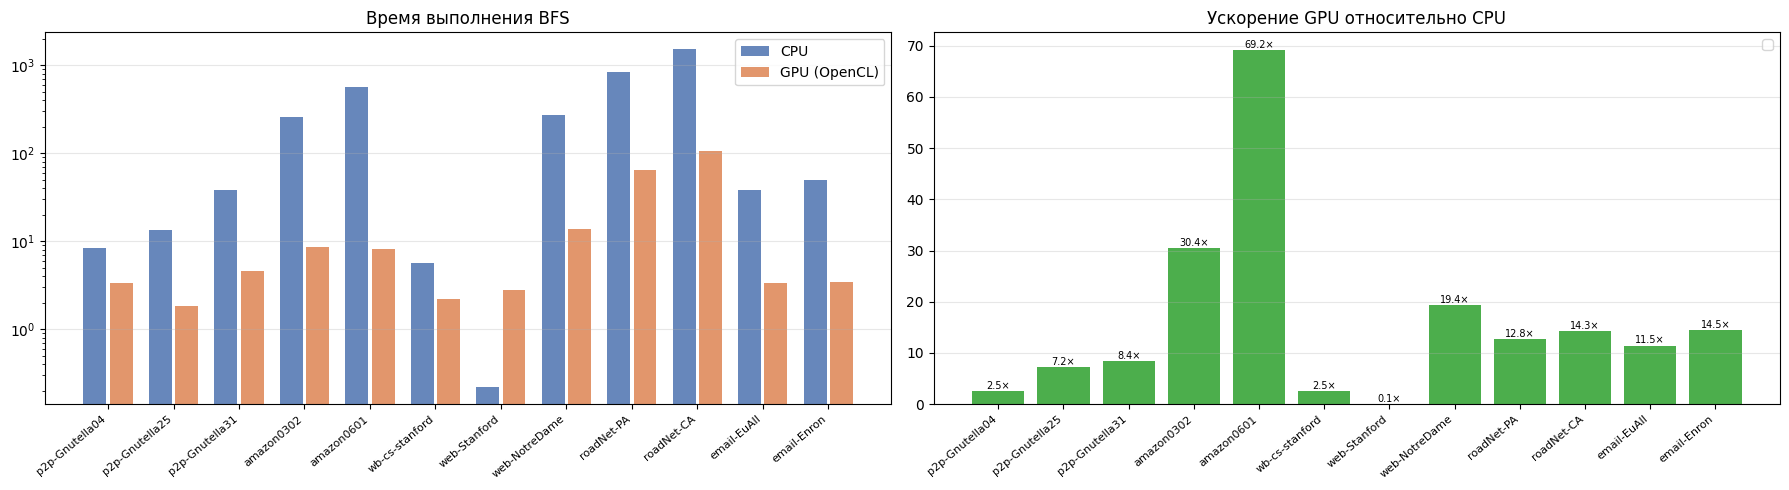

In [31]:
gpu = GPUBFS(verbose=True)

results = []
for name, A in graphs:
    try:
        results.append(run_experiment(name, A, gpu, n_runs=3))
    except Exception as e:
        print(f"[ERROR] {name}: {e}")

df = pd.DataFrame(results)

print("\n" + "="*80)
print("ИТОГОВАЯ ТАБЛИЦА")
print("="*80)
cols = ["name", "vertices", "edges", "avg_degree", "cpu_mean_ms", "gpu_mean_ms", "speedup", "correct"]
print(df[cols].to_string(index=False))
print(f"\nGPU быстрее CPU: {(df['speedup'] > 1).sum()} / {len(df)}")
print(f"Макс. ускорение: {df['speedup'].max():.2f}x  ({df.loc[df['speedup'].idxmax(), 'name']})")


# Графики

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

x      = range(len(df))
labels = df["name"]

# Время выполнения
ax = axes[0]
ax.bar([i - 0.2 for i in x], df["cpu_mean_ms"], 0.35, label="CPU",         color="#4C72B0", alpha=0.85)
ax.bar([i + 0.2 for i in x], df["gpu_mean_ms"], 0.35, label="GPU (OpenCL)", color="#DD8452", alpha=0.85)
ax.set_yscale("log")
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=40, ha="right", fontsize=8)
ax.set_title("Время выполнения BFS")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Сравнение скорости выполнения
ax = axes[1]
colors = ["#2ca02c" if s > 1 else "#d62728" for s in df["speedup"]]
bars = ax.bar(x, df["speedup"], color=colors, alpha=0.85)
for bar, s in zip(bars, df["speedup"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{s:.1f}×", ha="center", va="bottom", fontsize=7)
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=40, ha="right", fontsize=8)
ax.set_title("Ускорение GPU относительно CPU")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Вывод

В ходе работы был реализован алгоритм обхода в ширину на GPU с использованием OpenCL и проведено сравнение с классической CPU реализацией на 12 реальных графах из базы SuiteSparse Matrix Collection

GPU реализация оказалась быстрее CPU на 11 из 12 графов

Наибольший прирост показали графы с высокой средней степенью вершин и относительно малым диаметром — amazon0601, amazon0302, web-NotreDame, email-Enron. В таких графах каждый уровень BFS охватывает огромный фронтир, который GPU обрабатывает параллельно за одну итерацию ядра OpenCL, тогда как CPU вынужден обходить вершины последовательно через очередь

web-Stanford - единственный граф, где CPU оказался быстрее GPU — причём в 10 раз. Причина в том, что из 281K вершин BFS достиг лишь 259, а диаметр составил всего 2 уровня. Стартовая вершина оказалась в изолированной компоненте, фронтир так и не раскрылся, и накладные расходы на запуск ядра OpenCL полностью перекрыли само вычисление на CPU

Таким образом, эффективность GPU определяется не размером графа сам по себе, а соотношением размера фронтира и накладных расходов на запуск ядра